## **A. Steam 데이터 로딩 및 전처리**

In [1]:
#Google Drive 연결
from google.colab import drive
drive.mount('/content/drive')

#작업 디렉토리 설정
import os
drive_path = '/content/drive/MyDrive/RecSys/RecSys_Project/Data'
os.chdir(drive_path)

#위치 확인
print("Contents of the directory:")
!pwd

Mounted at /content/drive
Contents of the directory:
/content/drive/MyDrive/RecSys/RecSys_Project/Data


### **데이터프레임 변환**

**steam_user_data_filtered.csv**: **사용자**가 플레이한 게임 및 플레이 시간 데이터

-> **users_df**로 변환

**steamspy_detailed_games.csv**: **게임** 정보(개발사, 유통사, 장르 태그 등) 데이터

-> **games_df**로 변환



In [2]:
#필요한 라이브러리 import
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict


#재현성을 위한 random seed 고정
np.random.seed(42)
torch.manual_seed(42)

In [3]:
#.csv를 pandas dataframe으로 변환
user_data = pd.read_csv('steam_user_data_filtered.csv')
steam_data = pd.read_csv('steamspy_detailed_games.csv')

#dataframe 확인
display(user_data.head())
display(steam_data.head())

,steamid,game_name,appid,playtime_forever,achievements
0,'76561198828387620,Left 4 Dead 2,550,198.0,0.0
1,'76561198828387620,War Thunder,236390,0.0,0.0
2,'76561198828387620,theHunter Classic,253710,29.0,0.0
3,'76561198828387620,Card Hunter,293260,69.0,1.0
4,'76561198828387620,Star Trek Online,9900,9.0,0.0


,appid,name,developer,publisher,genre,owners,price,initialprice,languages,tags,score_rank,positive,negative
0,570,Dota 2,Valve,Valve,"Action, Strategy, Free To Play","200,000,000 .. 500,000,000",0.00,0.00,"English, Bulgarian, Czech, Danish, Dutch, Finn...","Free to Play(59993), MOBA(20198), Multiplayer(...",NaN,2014415,456637
1,730,Counter-Strike: Global Offensive,Valve,Valve,"Action, Free To Play","100,000,000 .. 200,000,000",0.00,0.00,"English, Czech, Danish, Dutch, Finnish, French...","FPS(91046), Shooter(65536), Multiplayer(62443)...",NaN,7573959,1154320
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.","Action, Adventure, Massively Multiplayer, Free...","50,000,000 .. 100,000,000",0.00,0.00,"English, Korean, Simplified Chinese, French, G...","Survival(14863), Shooter(12754), Battle Royale...",NaN,1506188,1031330
3,1623730,Palworld,Pocketpair,Pocketpair,"Action, Adventure, Indie, RPG, Early Access","50,000,000 .. 100,000,000",29.99,29.99,"English, Simplified Chinese, Traditional Chine...","Open World(1408), Survival(1295), Creature Col...",NaN,354964,22193
4,1172470,Apex Legends,Respawn,Electronic Arts,"Action, Adventure, Free To Play","50,000,000 .. 100,000,000",0.00,0.00,"English, French, Italian, German, Spanish - Sp...","Free to Play(2205), Battle Royale(1503), Multi...",NaN,663735,324641



###**데이터 전처리**

**게임 정보(games_df)**

appid, name, genre, tags 칼럼만 사용
결측치는 빈 문자열로 대체


**사용자 정보(users_df)**

플레이시간이 **5분 초과**인 데이터만 사용 (의미 없는 게임 실행 기록 제거)

In [4]:
#games_df에서는 게임명, 장르, 태그 데이터만 사용
games_df = steam_data[['appid', 'name', 'genre', 'tags']].copy()
games_df.fillna('', inplace=True)

#users_df에서는 사용자 id, addid, 플레이타임만 사용하고, 5분 이하로 플레이한 게임을 제외
users_df = user_data[user_data['playtime_forever'] > 5].copy()
users_df = users_df[['steamid', 'appid', 'playtime_forever']]

##**B. 번들 생성 & 그래프 구성**

### **게임 번들 생성**

**개별 게임 추천**: 높은 연산량, 인기 있는 극소수의 게임만 추천되는 Long Tail 문제 심화

**번들 단위 추천**: 유사한 10개의 게임을 '번들'로 묶고, 추천을 번들 단위로 수행함

**예시**: 사용자에세 문명 IV를 직접 추천하는 것보다는, 문명 시리즈 및 문명-라이크 게임을 추천하는 것이 더 다양하고 유의미한 추천이라고 볼 수 있음

**번들 생성 절차**
1. 장르 + 태그를 하나의 텍스트로 결합
2. TF-IDF 벡터화로 각 게임을 텍스트 임베딩으로 변환 (max_features는 메모리 폭증 방지)
3. Cosine similarity를 통해 하나의 게임에 가장 유사한 게임 9개를 선택(기준은 장르 + 태그)
4. 게임에 bundle_id 부여 및 dictionary 생성

**K-Means Clustering을 사용하지 않는 이유**

K-Means Clustering은 번들 크기의 편차가 심하기 때문에 게임당 가장 유사한 9개를 선택하여 번들을 생성하는 방법 사용


In [5]:
#Clustering을 통해서 게임을 번들로 묶음

#번들 데이터 저장
save_path = '/content/drive/MyDrive/RecSys/RecSys_Project/Data/games_with_bundles.pkl'
print("Checking for saved bundle data...")

#번들 크기 Hyperparameter
max_bundle_size = 10

#저장된 번들 데이터 없을 시, Clustering 시도
if os.path.exists(save_path):
    print(f"Found saved data at {save_path}. Loading...")
    games_df = pd.read_pickle(save_path)
    print("Data Loaded successfully!")

else:
    print("No saved data found. Starting Clustering...")

    # 태그와 장르 합쳐서 content로 만들고 vectorize
    games_df['content'] = games_df['genre'].astype(str) + ", " + games_df['tags'].astype(str)
    games_df['content'] = games_df['content'].fillna('')
    games_df['content'] = games_df['content'].astype(str)

    print("Vectorizing...")

    tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
    tfidf_matrix = tfidf.fit_transform(games_df['content'])  # (N, D) CSR sparse

    num_games = tfidf_matrix.shape[0]
    assigned = np.zeros(num_games, dtype=bool)
    bundle_ids = np.full(num_games, -1, dtype=int)

    current_bundle_id = 0

    print("Building bundles (each ≤ 10 games)...")

    for i in range(num_games):
        if assigned[i]:
            continue

        bundle_members = [i]
        assigned[i] = True

        #유사도 계산
        sims = tfidf_matrix[i].dot(tfidf_matrix.T).toarray().ravel()  # shape: (num_games,)
        sims[assigned] = -1e9  #이미 타 번들에 속한 경우

        remaining = (~assigned).sum()
        k = min(max_bundle_size - 1, remaining)

        #번들에 속할 아이템 선별
        if k > 0:
            top_idx = np.argpartition(-sims, k)[:k]

            for j in top_idx:
                if assigned[j]:
                    continue
                bundle_members.append(j)
                assigned[j] = True

        # bundle_id 부여
        for idx in bundle_members:
            bundle_ids[idx] = current_bundle_id

        current_bundle_id += 1

    games_df['bundle_id'] = bundle_ids

    print(f"Created {current_bundle_id} bundles (each ≤ {max_bundle_size} games).")
    print(f"Saving data to {save_path}...")
    games_df.to_pickle(save_path)
    print("Save Completed!")

#번들 개수
num_bundles = games_df['bundle_id'].nunique()

#번들 생성
print("Building Dictionaries...")
bundle_to_games = games_df.groupby('bundle_id')['name'].apply(list).to_dict()
game_to_bundle = games_df.set_index('appid')['bundle_id'].to_dict()
print("All Process Completed!")

Checking for saved bundle data...
Found saved data at /content/drive/MyDrive/RecSys/RecSys_Project/Data/games_with_bundles.pkl. Loading...
Data Loaded successfully!
Building Dictionaries...
All Process Completed!


###**사용자-번들 그래프 데이터 구성**

LightGCN 입력은

*  노드: User / Bundle

* 간선: User → Bundle 상호작용

여기서는 개별 게임이 아니라 Bundle을 Item으로 사용함.

**플레이타임 Log-Scaling**

*  원신(수백 시간) vs 인디게임(1–5시간)

*  이런 극단적 편차를 줄이기 위해 log1p 사용, 이후 MinMax Scaling으로 정규화

In [6]:
#그래프 데이터 구축
print("Building Graph Data...")

# User ID와 Bundle ID를 0부터 시작하는 index로 매핑
unique_users = users_df['steamid'].unique()
user_id_map = {id: i for i, id in enumerate(unique_users)}
users_df['user_idx'] = users_df['steamid'].map(user_id_map)

# 게임별 소속 bundle 정보를 user_df에 병합
users_df['bundle_id'] = users_df['appid'].map(game_to_bundle)
users_df.dropna(subset=['bundle_id'], inplace=True) # 매칭 안되는 게임 제거 (이부분도 데이터 전처리 요소 중 하나)
users_df['bundle_id'] = users_df['bundle_id'].astype(int)

# 플레이 시간을 점수(Rating)로 변환 (Log Scale 적용하여 편차 완화)
users_df['rating'] = np.log1p(users_df['playtime_forever'])
scaler = MinMaxScaler()
users_df['rating'] = scaler.fit_transform(users_df[['rating']])

# 번들 단위로 중복 제거 및 점수 합산 (한 번들에 여러 게임을 했을 경우)
interaction_df = users_df.groupby(['user_idx', 'bundle_id'])['rating'].max().reset_index()

Building Graph Data...


###**데이터셋 Split**

Train / Validation / Test를 무작위로 80 / 10 / 10 비율로 분리

In [7]:
# 데이터셋 분리 (Train: 80%, Val: 10%, Test: 10%)
train_val_df, test_df = train_test_split(interaction_df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, random_state=42)

# 데이터 텐서분
def to_tensor(df):
    edge_index = torch.tensor(df[['user_idx', 'bundle_id']].values.T, dtype=torch.long)
    values = torch.tensor(df['rating'].values, dtype=torch.float32)
    return edge_index, values

train_edge_index, train_values = to_tensor(train_df)
val_edge_index, val_values = to_tensor(val_df)
test_edge_index, test_values = to_tensor(test_df)

num_users = len(user_id_map)
num_items = num_bundles # item = bundle

print(f"Num Users: {num_users}, Num Bundles: {num_items}")

Num Users: 22472, Num Bundles: 7838


##**C. GNN 모델**

### **LightGCN 기반 GNN 모델**

게임을 묶어 만든 번들을 통해 연산량을 줄이는 기획 의도와 일관되게, 간단한 LightGCN을 기반으로 추천 모델을 구현한다.

**LightGCN 특징**



*   MLP 제거 → pure message passing
*   D⁻¹ᐟ² A D⁻¹ᐟ² 기반 propagation
*   skip-connection(각 layer embedding 평균)

을 기반으로 대규모 그래프에서 효율 추구

**LightGCN 구조**

*   User / Item embedding 학습
*   Sparse adjacency matrix 기반 propagation
*  Layer별 embedding 평균 → 최종 embedding



In [8]:
#LightGCN 모델 정
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, n_layers=3):
        super(LightGCN, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers

        # user 임베딩, item 임베딩 (학습 대상)
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def forward(self, adj_matrix):
        # 1. 초기 임베딩
        all_emb = torch.cat([self.user_embedding.weight, self.item_embedding.weight])
        embs = [all_emb]

        # 2. GNN Propagation (이웃 정보 집계)
        # LightGCN 공식: E^(k+1) = D^(-0.5) * A * D^(-0.5) * E^k
        # 여기서는 간단하게 A * E로 구현 (정규화된 adj_matrix 가정)
        for layer in range(self.n_layers):
            all_emb = torch.sparse.mm(adj_matrix, all_emb)
            embs.append(all_emb)

        # 3. 각 layer별 임베딩 평균 (Skip-connection 효과)
        final_emb = torch.stack(embs, dim=1).mean(dim=1)

        user_final, item_final = torch.split(final_emb, [self.num_users, self.num_items])
        return user_final, item_final

In [9]:
#정규화된 Sparse Adjacency Matrix (A_hat = D^(-1/2) * A * D^(-1/2)
def get_adj_matrix(edge_index, num_users, num_items):
    # user와 item 을 edge로 연결(양방향 간선)
    u, i = edge_index[0], edge_index[1]

    # adjacency matrix 구성을 위해 item 인덱스를 user 뒤로 미룸
    i = i + num_users

    full_u = torch.cat([u, i])
    full_i = torch.cat([i, u])
    values = torch.ones(len(full_u)) # 값 : 1

    # Sparse Tensor 생성
    indices = torch.stack([full_u, full_i])
    shape = (num_users + num_items, num_users + num_items)

    adj = torch.sparse_coo_tensor(indices, values, shape).coalesce()

    # ---- 정규화 과정 (Normalization) ----
    deg = torch.sparse.sum(adj, dim=1).to_dense() # 각 노드의 차수(degree)계산
    deg_inv_sqrt = deg.pow(-0.5) # 차수의 역제곱근 (D^-0.5) 계산 (0으로 나누기 방지) -> 이 부분은 잘 모르겠다..
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

    # 정규화된 값 계산: val_new = val_old * deg_inv[row] * deg_inv[col]
    # (LightGCN의 핵심 공식: D^-0.5 * A * D^-0.5)
    row, col = adj.indices()
    norm_values = deg_inv_sqrt[row] * deg_inv_sqrt[col]

    # 정규화된 값을 가진 새로운 Sparse Tensor 생성
    norm_adj = torch.sparse_coo_tensor(indices, norm_values, shape).coalesce()
    return norm_adj

### **GNN 학습**

Loss의 경우 MSE 대신 Cross Entropy도 사용해 보았으나, 연산량이 늘어나는데 반해 학습 정도가 오히려 떨어지는 부작용이 발생하여 MSE 사용 (아래 그래프는 CE를 사용했을 때의 그래프)

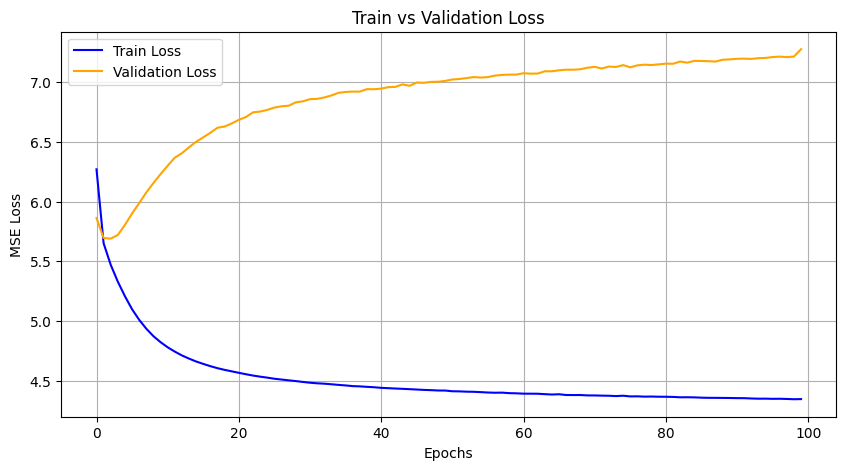

### **Hyperparameter 세팅**



*   Optimizer: Adam
*   Epoch: 100
*   Loss: MSE Loss



In [10]:
#모델 초기화 및 Hyperparameter 세팅
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = LightGCN(num_users, num_items).to(device) # 여기서 embedding 크기는 64로 했습니다. (젤 성능이 잘나옴)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

adj_matrix = get_adj_matrix(train_edge_index, num_users, num_items).to(device)
epochs = 100
loss_fn = nn.MSELoss()

train_loss_history = []
val_loss_history = []

Using device: cuda


### **Training / Validation**

**y hat = user_embedding * item_embedding**

평가 함수는 Dot-Product기반 implicit score prediction

In [11]:
# Validation 평가 함수
def evaluate(model, edge_index, values):
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model(adj_matrix)
        users = edge_index[0].to(device)
        items = edge_index[1].to(device)
        targets = values.to(device)

        preds = (user_emb[users] * item_emb[items]).sum(dim=1)
        loss = loss_fn(preds, targets)
    return loss.item()

In [12]:
#Training 루프
print("Start Training...")
best_val_loss = float('inf')

for epoch in tqdm(range(epochs)):
    # --- Training Step ---
    model.train()
    optimizer.zero_grad()

    user_emb, item_emb = model(adj_matrix)

    users = train_edge_index[0].to(device)
    items = train_edge_index[1].to(device)
    targets = train_values.to(device)

    preds = (user_emb[users] * item_emb[items]).sum(dim=1)

    loss = loss_fn(preds, targets)
    loss.backward()
    optimizer.step()

    train_loss = loss.item()
    train_loss_history.append(train_loss)

    # --- Validation Step ---
    val_loss = evaluate(model, val_edge_index, val_values)
    val_loss_history.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Training Completed!")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Start Training...


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.1167 | Val Loss: 0.0772
Epoch 2 | Train Loss: 0.0802 | Val Loss: 0.0977
Epoch 3 | Train Loss: 0.0967 | Val Loss: 0.0906
Epoch 4 | Train Loss: 0.0893 | Val Loss: 0.0693
Epoch 5 | Train Loss: 0.0683 | Val Loss: 0.0962
Epoch 6 | Train Loss: 0.1017 | Val Loss: 0.0700
Epoch 7 | Train Loss: 0.0701 | Val Loss: 0.0729
Epoch 8 | Train Loss: 0.0713 | Val Loss: 0.0812
Epoch 9 | Train Loss: 0.0796 | Val Loss: 0.0812
Epoch 10 | Train Loss: 0.0794 | Val Loss: 0.0734
Epoch 11 | Train Loss: 0.0716 | Val Loss: 0.0668
Epoch 12 | Train Loss: 0.0664 | Val Loss: 0.0732
Epoch 13 | Train Loss: 0.0759 | Val Loss: 0.0677
Epoch 14 | Train Loss: 0.0690 | Val Loss: 0.0638
Epoch 15 | Train Loss: 0.0628 | Val Loss: 0.0665
Epoch 16 | Train Loss: 0.0647 | Val Loss: 0.0669
Epoch 17 | Train Loss: 0.0650 | Val Loss: 0.0631
Epoch 18 | Train Loss: 0.0612 | Val Loss: 0.0579
Epoch 19 | Train Loss: 0.0565 | Val Loss: 0.0570
Epoch 20 | Train Loss: 0.0565 | Val Loss: 0.0576
Epoch 21 | Train Loss: 0.0575

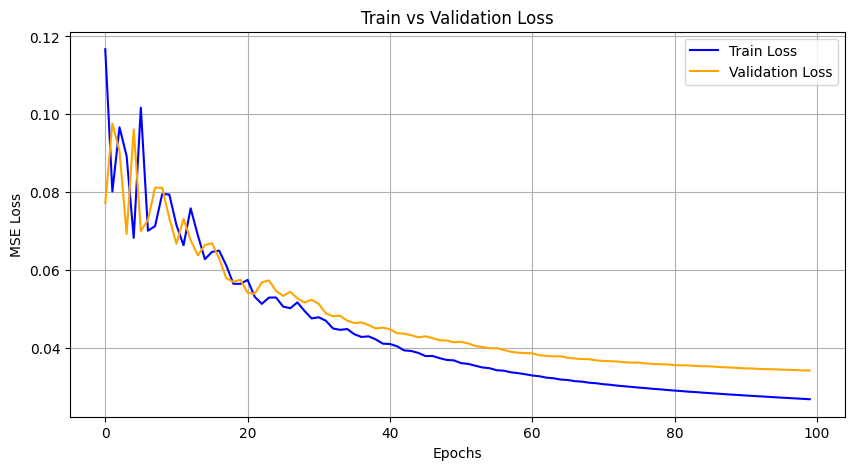

In [13]:
#Loss 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss', color='blue')
plt.plot(val_loss_history, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
#Test Set 기반 최종 Loss
test_loss = evaluate(model, test_edge_index, test_values)
print(f"Final Test Loss (MSE): {test_loss:.4f}")

Final Test Loss (MSE): 0.0341


## **D. 게임 번들 추천**

### **번들 추천**

LightGCN에서 학습한
*   사용자 임베딩
*   번들 임베딩

을 사용하여 각 번들에 대한 내적 기반 점수 계산

= "유저의 취향 벡터와 가장 비슷한 번들 추천"

추천 결과의 해석을 위해
1. 유저 플레이 히스토리 분석
2. 추천 번들 내부 게임들의 공통 태그 분석

### **번들 추천 함수**

추천 단계는 다음과 같음
1. 유저 존재 여부 확인
2. 플레이 기록(Top 5 게임) 분석
3. LightGCN 기반 점수 계산
4. 상위 K개 번들을 추천
5. 번들에 포함된 게임 요약 태그 출력

In [15]:
def recommend_bundles(user_steam_id, top_k=3):
    model.eval()

    # 1. 유저 존재 여부 확인
    if user_steam_id not in user_id_map:
        print(f"User {user_steam_id} not found in training data.")
        return

    u_idx = user_id_map[user_steam_id]

    # 2. 유저의 과거 플레이 기록 분석 (History)
    # users_df는 전체 데이터이므로, 여기서 해당 유저의 기록을 조회
    user_history = users_df[users_df['steamid'] == user_steam_id].sort_values(by='playtime_forever', ascending=False)
    top_played_games = user_history.head(5)

    print(f"\n{'='*60}")
    print(f" 🎮 User Analysis: {user_steam_id}")
    print(f"{'='*60}")
    print("Top 5 Played Games (Past History):")
    if not top_played_games.empty:
        for _, row in top_played_games.iterrows():
            # 게임 이름 찾기
            g_name_series = games_df[games_df['appid'] == row['appid']]['name']
            g_name = g_name_series.values[0] if len(g_name_series) > 0 else "Unknown Game"

            # 게임 장르 찾기
            g_genre_series = games_df[games_df['appid'] == row['appid']]['genre']
            g_genre = g_genre_series.values[0] if len(g_genre_series) > 0 else "Unknown Genre"

            print(f" - {g_name} (Genre: {g_genre})")
    else:
        print(" - No play history found in dataset.")

    # 3. 모델을 이용한 추천 점수 계산 (Prediction)
    with torch.no_grad():
        user_emb, item_emb = model(adj_matrix)
        u_vector = user_emb[u_idx]

        # 모든 번들과의 내적(유사도) 계산
        scores = torch.matmul(item_emb, u_vector)

    # 상위 K개 번들 추출
    top_indices = torch.topk(scores, top_k).indices.cpu().numpy()

    # 4. 추천 결과 출력
    print(f"\n{'='*60}")
    print(f" ✨ AI Recommendations (Top {top_k} Bundles)")
    print(f"{'='*60}")

    for rank, bundle_idx in enumerate(top_indices):
        games_in_bundle = bundle_to_games.get(bundle_idx, [])
        score = scores[bundle_idx].item()

        # 번들 내 게임들의 주요 태그/장르 분석하여 키워드 뽑기
        all_tags = []
        for g_name in games_in_bundle:
            # 게임 이름으로 태그 데이터 검색
            tag_data = games_df[games_df['name'] == g_name]['tags'].values
            if len(tag_data) > 0:
                # 태그 문자열 처리 (예: "FPS, Action")
                all_tags.extend([t.strip() for t in str(tag_data[0]).split(',')])

        # 가장 흔한 태그 3개 추출
        if all_tags:
            common_tags = [tag for tag, count in Counter(all_tags).most_common(5)]
            tags_str = ", ".join(common_tags)
        else:
            tags_str = "No Tags"

        print(f"\n[Rank {rank+1}] Bundle Score: {score:.4f}")
        print(f"Key Themes: {tags_str} ...")
        print(f"Games included ({len(games_in_bundle)} games):")

        # 번들 안의 게임 목록 (최대 5개 표시)
        for g in games_in_bundle[:5]:
            print(f"  └─ {g}")

        if len(games_in_bundle) > 5:
            print(f"     ... and {len(games_in_bundle)-5} more games")

In [16]:
# --- 테스트 실행 ---
# 데이터셋에 있는 첫 번째 유저 아이디를 가져와서 테스트
if len(unique_users) > 0:
    test_target_user = unique_users[0]
    recommend_bundles(test_target_user)
else:
    print("No users found.")


 🎮 User Analysis: '76561198828387620
Top 5 Played Games (Past History):
 - Metaphor: ReFantazio (Genre: Action, Adventure, RPG)
 - Dragon's Dogma 2 (Genre: Action, RPG)
 - ELDEN RING (Genre: Action, RPG)
 - Cube Racer (Genre: Action, Casual, Indie, Racing)
 - Monster Hunter: World (Genre: Action)

 ✨ AI Recommendations (Top 3 Bundles)

[Rank 1] Bundle Score: 0.3757
Key Themes: Co-op(25), FPS(91046), Shooter(65536), Multiplayer(62443), Competitive(53469) ...
Games included (10 games):
  └─ Counter-Strike: Global Offensive
  └─ World of Warships
  └─ Splitgate: Arena Warfare
  └─ Soccer Online: Ball 3D
  └─ Warfork
     ... and 5 more games

[Rank 2] Bundle Score: 0.2788
Key Themes: Action(25), Racing(25), Indie(25), Casual(25), Multiplayer(9) ...
Games included (10 games):
  └─ Cube Racer
  └─ Sunny Hillride
  └─ Impossible Runner
  └─ The Secret of Pineview Forest
  └─ Fruit Postal Service
     ... and 5 more games

[Rank 3] Bundle Score: 0.2742
Key Themes: Local Multiplayer(162), Rea

###**추천 성능 Evalutation**

**지표**

1. Ground Truth
- Test 데이터에서 해당 유저가 실제로 상호작용한 번들 집합
- `T_u = {test에서 등장한 bundle_id 들}`



2. Model Prediction (Top-K)
- LightGCN이 추천한 상위 K개의 번들 집합  
- `P_u(k) = {Top-K recommended bundle_id}`

3. Precision@K
- 추천한 K개 중에서 정답인 번들의 비율  
- `Precision@K = |T_u ∩ P_u(k)| / K`

4. Recall@K
- 정답 중에서 얼마나 맞추었는지  
- `Recall@K = |T_u ∩ P_u(k)| / |T_u|`

5. Hit Rate@K
- Top-K 중 정답이 하나라도 포함되면 Hit (1), 아니면 0  
- `Hit@K = 1 if |T_u ∩ P_u(k)| > 0 else 0`


**지표 유의사항 및 계산 예시**

다만, 게임을 묶는 Bundle 특성상 해당 지표들이 다소 너그럽게 작용함.

예를 들어 User가 게임 A, B, C, D, E를 플레이했을 때,

Bundle 1: A, F, G ...

Bundle 2: B, C, H ...

Bundle 3: D, E, K...

라고 번들 단계에서 묶이고, Bundle 1, 2가 train, 3가 test라고 하면, Bundle 1, 2가 임베딩을 만드는 training 단계에서 쓰이고, 모델이 추천한 번들이 실제 3을 포함하는지가 지표 계산에 사용됨

**평가 지표 계산 시 유의사항**

*   처음 코드를 만들었을 때는, 사용자가 상호작용한 모든 번들을 정답으로 인정했기 때문에 지표가 과대평가되는 문제가 있었음 (Train에서 본 번들을 후보군에서 빼지 않음)

*   하지만 이는 추천에서 논리적으로 문제(이미 플레이한 게임을 추천하는 것은 옳지 않음)가 되었기 때문에, 수정함

현재 버전에서는
*   Test에서 등장한 번들만 정답으로 사용, Train 등장 번들 제외

**Sequential?**

현재는 Sequential한 추천은 아님. 유저가 게임을 언제 플레이한지 알 수 없기 때문
*   지금은 다음과 같은 추천으로 볼 수 있음: 데이터에서 유저가 ABCDEF를 플레이했을 때, CD를 가리고, 남은 기록을 바탕으로 유저가 플레이했을 법할 게임을 맞추기

In [17]:
import numpy as np
from tqdm.notebook import tqdm

def evaluate_average_performance(model, test_df, k_list=[3, 5, 10]):
    """
    전체 Test 유저에 대해 추천 성능 지표(Precision, Recall, Hit Rate)의 평균을 계산합니다.
    """
    model.eval()

    # 평가 대상 유저 (Test Set에 있는 유저들)
    test_users = test_df['user_idx'].unique()
    print(f"Calculating average metrics for {len(test_users)} users...")

    # 결과 저장을 위한 딕셔너리
    metrics = {k: {'precision': [], 'recall': [], 'hit_rate': []} for k in k_list}

    with torch.no_grad():
        # 전체 임베딩 계산 (한 번만 수행)
        user_emb, item_emb = model(adj_matrix)

        # 배치 단위 처리 (메모리 절약 및 속도 향상)
        batch_size = 1024
        for i in tqdm(range(0, len(test_users), batch_size)):
            batch_users = test_users[i : i + batch_size]

            # 배치 유저의 벡터 가져오기
            u_vectors = user_emb[batch_users]  # (batch_size, emb_dim)

            # 점수 계산 (Batch Users x All Bundles)
            scores = torch.matmul(u_vectors, item_emb.t())

            for idx, u_idx in enumerate(batch_users):
                # 정답셋 (Ground Truth)
                true_bundles = set(test_df[test_df['user_idx'] == u_idx]['bundle_id'].values)
                if len(true_bundles) == 0: continue

                # 유저별 점수
                user_scores = scores[idx]

                for k in k_list:
                    # Top-K 추천 번들 인덱스
                    top_k_indices = torch.topk(user_scores, k).indices.cpu().numpy()
                    pred_bundles = set(top_k_indices)

                    # 맞춘 개수
                    hit_count = len(true_bundles & pred_bundles)

                    metrics[k]['precision'].append(hit_count / k)
                    metrics[k]['recall'].append(hit_count / len(true_bundles))
                    metrics[k]['hit_rate'].append(1 if hit_count > 0 else 0)

    # 결과 출력
    print(f"\n{'='*50}")
    print(" 📊 Average Performance Across All Test Users")
    print(f"{'='*50}")

    for k in k_list:
        avg_p = np.mean(metrics[k]['precision'])
        avg_r = np.mean(metrics[k]['recall'])
        avg_h = np.mean(metrics[k]['hit_rate'])

        print(f"[Top-{k}] Precision: {avg_p:.4f} | Recall: {avg_r:.4f} | Hit Rate: {avg_h:.4f}")

# 실행
evaluate_average_performance(model, test_df)

Calculating average metrics for 17285 users...


  0%|          | 0/17 [00:00<?, ?it/s]


 📊 Average Performance Across All Test Users
[Top-3] Precision: 0.0925 | Recall: 0.1219 | Hit Rate: 0.2588
[Top-5] Precision: 0.0772 | Recall: 0.1565 | Hit Rate: 0.3421
[Top-10] Precision: 0.0570 | Recall: 0.2095 | Hit Rate: 0.4620


## **F.Negative Sampling 활용 모델 파인튜닝**

###**BPR(Baysian Personalized Ranking)**

이 단계에서는 MSE 대신 BPR기반 학습을 사용해서 Negative Sampling의 효과를 탐색한다.

이 과정은 다음의 네 단계로 구성된다.
1. (A) Negative Sampling: 유저가 하지 않은 번들 샘플링  
2. (B) BPR Loss 정의: (u, i, j) 삼중쌍에 대한 pairwise ranking 손실  
3. (C) BPR Fine-tuning: 기존 모델을 BPR로 미세조정  
4. (D) Test Evaluation: Test 세트 기준 성능 측정

### **Negative Sampling**
Negative Sampling에서는, 유저가 플레이 기록이 없는 게임만을 포함하는 번들을 무작위로 샘플링한다.

처음에는 모델에서 Similarity가 낮은 번들을 선택했으나, 성능이 감소하였다. 이는 오히려 similarity가 낮다고 유저가 플레이하지 않을 것이라고(negative sample이라고 확정) 간주하는 것이 틀린 접근임을 보여준다.

In [18]:
#실제 플레이한 번들

user_pos_bundles = defaultdict(set)
for u, b in zip(train_df['user_idx'].values, train_df['bundle_id'].values):
    user_pos_bundles[u].add(b)

all_bundles = np.arange(num_items)

model.eval()
with torch.no_grad():
    user_emb, item_emb = model(adj_matrix)

neg_pairs = []

#Negative Sample 크기

n_neg_per_user = 1

#상호작용하지 않은 번들을 무작위로 샘플
for u in tqdm(range(num_users)):
    pos = np.array(list(user_pos_bundles[u]))
    if len(pos) == 0:
        continue

    scores = torch.matmul(user_emb[u], item_emb.t()).cpu().numpy()

    #이미 플레이한 번들
    scores[pos] = -np.inf


    candidates = np.setdiff1d(np.arange(num_bundles), pos)  # 아직 안 한 번들들
    if len(candidates) < n_neg_per_user:
        neg_idx = candidates
    else:
        neg_idx = np.random.choice(candidates, size=n_neg_per_user, replace=False)


    for j in neg_idx:
        neg_pairs.append((u, int(j)))

neg_df = pd.DataFrame(neg_pairs, columns=['user_idx', 'bundle_id'])

  0%|          | 0/22472 [00:00<?, ?it/s]

### **BPR Loss**

유저에 대해 실제로 플레이한 번들의 점수가 플레이하지 않은 번들의 점수보다 높아지도록 학습

In [19]:
#BPR Loss 정의

def bpr_loss(user_emb, item_emb, users, pos_items, neg_items, lambda_reg=1e-4):

    u_e = user_emb[users]
    i_e = item_emb[pos_items]
    j_e = item_emb[neg_items]   # (B, d)

    pos_scores = (u_e * i_e).sum(dim=1)
    neg_scores = (u_e * j_e).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

    reg = (u_e.norm(2, dim=1).pow(2) +
           i_e.norm(2, dim=1).pow(2) +
           j_e.norm(2, dim=1).pow(2)).mean()

    return loss + lambda_reg * reg

In [20]:
#user별 negative
user_neg_list = defaultdict(list)
for u, b in zip(neg_df['user_idx'].values, neg_df['bundle_id'].values):
    user_neg_list[u].append(b)

train_u = train_df['user_idx'].values
train_i = train_df['bundle_id'].values
train_j = []

rng = np.random.default_rng(42)

#Negative sample 존재 안할 시, 양성에 없는 번들 중 랜덤으로 샘플링
#Negative Sample 존재 시 해당 negative sample 중 하나 선택

for u in train_u:
    negs = user_neg_list[u]
    if len(negs) == 0:
        while True:
            j = rng.integers(low=0, high=num_items)
            if j not in user_pos_bundles[u]:
                train_j.append(int(j))
                break
    else:
        j = rng.choice(negs)
        train_j.append(int(j))

train_u_tensor = torch.tensor(train_u, dtype=torch.long, device=device)
train_i_tensor = torch.tensor(train_i, dtype=torch.long, device=device)
train_j_tensor = torch.tensor(train_j, dtype=torch.long, device=device)

print("BPR용 triple tensor 준비 완료:")
print("  users :", train_u_tensor.shape)
print("  pos   :", train_i_tensor.shape)
print("  neg   :", train_j_tensor.shape)

BPR용 triple tensor 준비 완료:
  users : torch.Size([771943])
  pos   : torch.Size([771943])
  neg   : torch.Size([771943])


### **BPR Fine-tuning**

Train에서 관측된 (u, i)에 대해 (u, i, j-negative sample)을 만듦.

그 다음, BPR epoch마다:

1. `(u, i, j)` triple들을 섞어서(mini-batch SGD)
2. `model(adj_matrix)` 로 현재 user/item 임베딩을 다시 계산하고
3. `bpr_loss(user_emb, item_emb, u_batch, i_batch, j_batch)` 를 구해
4. `loss.backward()` 와 `optimizer.step()` 으로 파라미터 업데이트

이 과정을 통해 모델은:

- 이 유저는 i 번들을 선호하고, j 번들은 덜 선호한다”는 방향으로  
  랭킹 구조를 점점 더 정교하게 학습하게 된다

In [21]:
#BPR 파인튜닝 실
bpr_epochs = 5
batch_size = 4096

print("\n[Stage 2] BPR Fine-tuning 시작...")

for epoch in range(bpr_epochs):
    model.train()
    permutation = torch.randperm(train_u_tensor.size(0), device=device)
    epoch_loss = 0.0
    total_examples = 0

    for start in range(0, train_u_tensor.size(0), batch_size):
        idx = permutation[start:start+batch_size]
        u_batch = train_u_tensor[idx]
        i_batch = train_i_tensor[idx]
        j_batch = train_j_tensor[idx]

        optimizer.zero_grad()

        user_emb, item_emb = model(adj_matrix)

        loss = bpr_loss(user_emb, item_emb, u_batch, i_batch, j_batch)
        loss.backward()
        optimizer.step()

        batch_size_actual = u_batch.size(0)
        epoch_loss += loss.item() * batch_size_actual
        total_examples += batch_size_actual

    avg_loss = epoch_loss / total_examples
    print(f"[BPR Epoch {epoch+1}/{bpr_epochs}] Loss: {avg_loss:.4f}")


[Stage 2] BPR Fine-tuning 시작...
[BPR Epoch 1/5] Loss: 0.1234
[BPR Epoch 2/5] Loss: 0.0503
[BPR Epoch 3/5] Loss: 0.0306
[BPR Epoch 4/5] Loss: 0.0205
[BPR Epoch 5/5] Loss: 0.0149


In [22]:
evaluate_average_performance(model, test_df)

Calculating average metrics for 17285 users...


  0%|          | 0/17 [00:00<?, ?it/s]


 📊 Average Performance Across All Test Users
[Top-3] Precision: 0.0946 | Recall: 0.1186 | Hit Rate: 0.2640
[Top-5] Precision: 0.0813 | Recall: 0.1577 | Hit Rate: 0.3567
[Top-10] Precision: 0.0629 | Recall: 0.2214 | Hit Rate: 0.4982


## **G. LLM을 활용한 게임 추천**


## **개별 추천**

LightGCN은 번들 단위 추천을 수행
*   LLM을 통해서 그 번들(10개 게임 묶음) 안에서 상세 추천

**LLM 번들 추천 단계**

1. 번들 내부 게임 메타데이터 요약
2. LLM을 통해서 번들 내부 게임 순위화
3. LLM 순위 기반 HitRate/NDCG 평가

In [23]:
#게임 메타데이터 요약 및 매핑
steam_detail_df = steam_data.copy()
steam_detail_df['genre'] = steam_detail_df['genre'].fillna('')
steam_detail_df['tags'] = steam_detail_df['tags'].fillna('')
if 'price' in steam_detail_df.columns:
    steam_detail_df['price'] = steam_detail_df['price'].fillna(0)
else:
    steam_detail_df['price'] = 0.0

#appid -> {genre, tags, preice}
game_detail_summary = {}
for _, row in steam_detail_df.iterrows():
    aid = row['appid']
    game_detail_summary[aid] = {
        "genre": row['genre'],
        "tags": row['tags'],
        "price": row['price'],
    }

#appid -> name
appid_to_name = games_df.set_index('appid')['name'].to_dict()

#use_idx -> steamid
idx_to_steamid = {idx: sid for sid, idx in user_id_map.items()}

### **LLM 입력용 사용자/후보 데이터 준비**

LightGCN 만들어진 번들 추천 기반
*   LLM 판단 Candidate game list
*   LLM 전달 사용자 과거 기록 구성

In [24]:
# 1) train 데이터에 실제로 등장한 user_idx만 사용
train_user_ids = set(train_df['user_idx'])

# 2) users_df에서 해당 user들의 플레이 로그만 필터링
#    (LLM 프롬프트에 넣어줄 "과거 플레이 이력"용)
train_users_df = users_df[users_df['user_idx'].isin(train_user_ids)].copy()

# 3) 유저별 과거에 했던 게임 집합 (appId 기준)
#    → LLM 후보에서 이미 플레이한 게임은 빼기 위해 사용
user_history_games = defaultdict(set)
for _, row in train_users_df.iterrows():
    u = row['user_idx']
    app = row['appid']
    user_history_games[u].add(app)

# 4) 유저별 테스트 정답 게임 집합 (bundle → appId로 풀어서 만든 ground truth)
#    test_df: (user_idx, bundle_id, rating)
user_to_test_games = defaultdict(set)
for _, row in test_df.iterrows():
    u = row['user_idx']
    b = row['bundle_id']

    # 해당 번들에 포함된 게임들 (appid들) 찾기
    apps = games_df[games_df['bundle_id'] == b]['appid'].unique()
    user_to_test_games[u].update(apps)

### **LLM Prompt 구성 함수**

**LLM에 들어가는 데이터**
1. 사용자 과거 게임 요약
2. 후보 게임 요약
3. 순위 요청

**평가지표 개선**

이전에는, 번들 안에 Train에 사용된 데이터가 프롬프트에 들어가서 지표과 과대평가되는 현상이 존재했음 (Test train split logic에서 오류)

이를 개선하기 위해, 현재는 LLM이 ranking할 후보 게임에는 train에서 주어진 플레이한 게임이 절대 포함되지 않도록 개선


In [25]:
from openai import OpenAI

client = OpenAI(api_key="YOUR_OPENAI_API_KEY")  # TODO: 키 넣기

In [26]:
# 게임 메타데이터 요약
def summarize_game(appid):
    d = game_detail_summary.get(appid, {})
    name = appid_to_name.get(appid, f"Game_{appid}")
    genre = d.get("genre", "")
    tags = d.get("tags", "")
    price = d.get("price", "")
    return f"{name} | Genre: {genre} | Tags: {tags} | Price: {price}"

#프롬프트 구성
def build_prompt_rank_all(user_steam_id, candidate_appids, top_m=10):
    user_hist = train_users_df[train_users_df['steamid'] == user_steam_id].copy()

    if user_hist.empty:
        hist_names, hist_play, hist_rate = [], [], []
    else:
        user_hist = user_hist.sort_values('playtime_forever', ascending=False).head(8)
        hist_appids = user_hist['appid'].tolist()
        hist_names = [appid_to_name.get(a, f"Game_{a}") for a in hist_appids]
        hist_play = user_hist['playtime_forever'].round(1).tolist()
        hist_rate = user_hist['rating'].round(3).tolist()

    if top_m is not None:
        cand_appids = candidate_appids[:top_m]
    else:
        cand_appids = candidate_appids

    cand_summaries = [summarize_game(aid) for aid in cand_appids]
    cand_names = [appid_to_name.get(aid, f"Game_{aid}") for aid in cand_appids]
    cand_block = "\n".join(f"- {s}" for s in cand_summaries)

    prompt = f"""
The user's past game play information:
- Game names: {hist_names}
- Playtimes: {hist_play}
- Ratings: {hist_rate}

Candidate games (with brief metadata):
{cand_block}

Task:
Rank ALL candidate games from most likely to be enjoyed by this user
to least likely. Consider similarity of genre/tags, reasonable price,
and the user's playtime and rating patterns.

Return only the ordered list of game names, separated by commas.
For example:
Game A, Game B, Game C, ...
"""
    return prompt.strip(), cand_names, cand_appids

### LLM 응답 파싱 + 평가지표 계산

**평가 함수**

*   Hit@k
*   NDCG@k

In [27]:
def call_llm_rank(prompt):
    resp = client.chat.completions.create(
        model="gpt-4.1-nano",
        messages=[
            {"role": "system", "content": "You are a concise ranking model."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.0,
        max_tokens=128,
    )
    return resp.choices[0].message.content.strip()

def parse_ranked_list(output, candidate_names):
    raw = [x.strip() for x in output.split(",") if x.strip()]
    ranked = []

    for item in raw:
        if item in candidate_names:
            if item not in ranked:
                ranked.append(item)
            continue
        partial = [c for c in candidate_names if item.lower() in c.lower()]
        if len(partial) == 1 and partial[0] not in ranked:
            ranked.append(partial[0])

    for c in candidate_names:
        if c not in ranked:
            ranked.append(c)

    return ranked

import math

def dcg_at_k(rels):
    dcg = 0.0
    for i, rel in enumerate(rels, 1):
        if rel > 0:
            dcg += rel / math.log2(i + 1)
    return dcg

def ndcg_at_k(rels):
    dcg = dcg_at_k(rels)
    ideal = sorted(rels, reverse=True)
    idcg = dcg_at_k(ideal)
    if idcg == 0:
        return 0.0
    return dcg / idcg

In [28]:
def evaluate_llm_rank_in_bundle(model, test_df, bundle_k=1, item_k=5, max_users=200):
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model(adj_matrix)

    test_user_indices = test_df['user_idx'].unique()
    if max_users is not None and len(test_user_indices) > max_users:
        np.random.shuffle(test_user_indices)
        test_user_indices = test_user_indices[:max_users]

    hit_list = []
    ndcg_list = []

    for u_idx in tqdm(test_user_indices, desc="LLM Ranking Evaluation"):
        steam_id = idx_to_steamid[u_idx]
        true_games = user_to_test_games.get(u_idx, set())
        if not true_games:
            continue

        u_vec = user_emb[u_idx]
        scores = torch.matmul(item_emb, u_vec)
        top_bundles = torch.topk(scores, bundle_k).indices.cpu().numpy()


        # 과거 플레이 게임을 명시적으로 제거, LLM이 ranking할 후보 게임에는 test 플레이 게임이 절대 포함되지 않도록 하고, 만약 포함되어도 LLM 후보군에서 제거
        candidate_appids = []
        for b in top_bundles:
            apps = games_df[games_df['bundle_id'] == int(b)]['appid'].unique().tolist()
            candidate_appids.extend(apps)

        candidate_appids = list(set(candidate_appids))  # 중복 제거

        history_games = user_history_games.get(u_idx, set())
        candidate_appids = [aid for aid in candidate_appids if aid not in history_games]


        if len(candidate_appids) == 0:
            continue

        prompt, cand_names, cand_appids = build_prompt_rank_all(
            user_steam_id=steam_id,
            candidate_appids=candidate_appids,
            top_m=10,
        )

        llm_out = call_llm_rank(prompt)
        ranked_names = parse_ranked_list(llm_out, cand_names)

        name_to_appid_local = {
            appid_to_name[aid]: aid
            for aid in cand_appids
            if aid in appid_to_name
        }

        ranked_appids = []
        for nm in ranked_names:
            aid = name_to_appid_local.get(nm)
            if aid is not None and aid not in ranked_appids:
                ranked_appids.append(aid)
        for aid in cand_appids:
            if aid not in ranked_appids:
                ranked_appids.append(aid)

        top_k_items = ranked_appids[:item_k]
        rels = [1 if app in true_games else 0 for app in top_k_items]

        hit_list.append(1 if any(rels) else 0)
        ndcg_list.append(ndcg_at_k(rels))

    print(f"[LLM Item-Ranking] HitRate@{item_k}: {np.mean(hit_list):.4f}")
    print(f"[LLM Item-Ranking] NDCG@{item_k}: {np.mean(ndcg_list):.4f}")

### **Evaluation**

**bundle_k**

bundle_k는 랭킹을 매길 때 몇개의 번들을 참고할 것인지를 뜻한다.

예시로, bundle_k = 1이면 LightGCN이 사용자에게 번들을 1개 추천(10개 게임)하고, 그 안에서 LLM이 순위를 배기는 것이다.

bundle_k = 3이면 LightGCN이 사용자에게 번들을 3개 추천(30개 게임)하고, 그 안에서 LLM이 순위를 매기는 것이다.

bundle_k 순위가 늘어날수폭 평가 지표가 늘어나지만, LLM 토큰 호출 또한 늘어난다.

In [42]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=3,
    item_k=3,
    max_users=1000,
)

LLM Ranking Evaluation:   0%|          | 0/1000 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@3: 0.1920
[LLM Item-Ranking] NDCG@3: 0.1445


In [43]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=5,
    item_k=5,
    max_users=1000,
)

LLM Ranking Evaluation:   0%|          | 0/1000 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@5: 0.2400
[LLM Item-Ranking] NDCG@5: 0.1596


In [30]:
evaluate_llm_rank_in_bundle(
   model,
    test_df,
    bundle_k=10,
    item_k=10,
    max_users=1000,
)

LLM Ranking Evaluation:   0%|          | 0/1000 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@10: 0.3420
[LLM Item-Ranking] NDCG@10: 0.1748


가장 우수한 bundle_k, item_k 조합의 실험

In [32]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=3,
    item_k=3,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@3: 0.2600
[LLM Item-Ranking] NDCG@3: 0.2035


In [33]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=1,
    item_k=3,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@3: 0.0900
[LLM Item-Ranking] NDCG@3: 0.0900


In [34]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=5,
    item_k=3,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@3: 0.1100
[LLM Item-Ranking] NDCG@3: 0.0947


In [35]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=10,
    item_k=3,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@3: 0.0800
[LLM Item-Ranking] NDCG@3: 0.0505


In [36]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=10,
    item_k=5,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@5: 0.2100
[LLM Item-Ranking] NDCG@5: 0.1439


In [37]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=5,
    item_k=5,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@5: 0.2300
[LLM Item-Ranking] NDCG@5: 0.1469


In [38]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=3,
    item_k=5,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@5: 0.2300
[LLM Item-Ranking] NDCG@5: 0.1510


In [40]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=10,
    item_k=10,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@10: 0.3200
[LLM Item-Ranking] NDCG@10: 0.1797


In [39]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=5,
    item_k=10,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@10: 0.2900
[LLM Item-Ranking] NDCG@10: 0.1774


In [41]:
evaluate_llm_rank_in_bundle(
    model,
    test_df,
    bundle_k=3,
    item_k=10,
    max_users=100,
)

LLM Ranking Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

[LLM Item-Ranking] HitRate@10: 0.2500
[LLM Item-Ranking] NDCG@10: 0.1501
